# Imports

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arff
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# Data loading

In [6]:
ROOT = Path.cwd()

if ROOT.name == 'notebooks':
    DATA_PATH = ROOT.parent / 'credit'
else:
    DATA_PATH = 'credit'
    
with open(DATA_PATH, 'r') as f:
    arff_data = arff.load(f)
    
data = arff_data['data']
column_names = [attr[0] for attr in arff_data['attributes']]
    
df = pd.DataFrame(data, columns=column_names)
df.head()

,Loan_ID,Loan_Amount_Requested,Length_Employed,Home_Owner,Annual_Income,Income_Verified,Purpose_Of_Loan,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Gender,Interest_Rate
0,10139122,"35,000",3 years,NaN,160000.0,VERIFIED - income,credit_card,14.86,1,NaN,6,26,Male,None
1,10025461,"15,000",10+ years,Rent,41000.0,not verified,debt_consolidation,16.51,0,21.0,13,36,Female,None
2,10154747,"11,000",5 years,Mortgage,59000.0,not verified,debt_consolidation,21.75,0,NaN,11,20,Male,None
3,10032437,"12,000",NaN,Mortgage,72000.0,VERIFIED - income,debt_consolidation,15.73,1,NaN,7,20,Female,None
4,10060564,"20,000",< 1 year,Other,79404.0,VERIFIED - income,debt_consolidation,15.32,3,58.0,18,33,Female,None


# Analiza 1 - Gender vs Debt_To_Income
Sprawdzenie, czy wskaźnik zadłużenia względem dochodu (Debt_To_Income) różni się między kobietami i mężczyznami.

* H₀: Średnia wartość Debt_To_Income jest taka sama dla kobiet i mężczyzn.
* H₁: Średnia wartość Debt_To_Income różni się między kobietami i mężczyznami.

Zmienne:
* Debt_To_Income - ilościowa
* Gender - dwie niezależne grupy

Testy:
- t Welcha
- U Manna-Whitneya

# Przygotowanie danych

In [3]:
female = df.loc[df["Gender"] == "Female", "Debt_To_Income"].dropna()
male = df.loc[df["Gender"] == "Male", "Debt_To_Income"].dropna()

print("Female:", len(female))
print("Male:", len(male))

Female: 9319
Male: 23543


# Statystyki opisowe

In [4]:
summary = (
    df.groupby("Gender")["Debt_To_Income"]
      .agg(["count", "mean", "median", "std"])
)

summary

,count,mean,median,std
Gender,,,,
Female,9319,17.267325,16.90,7.896299
Male,23543,17.201857,16.83,7.832245


# Wizualizacja

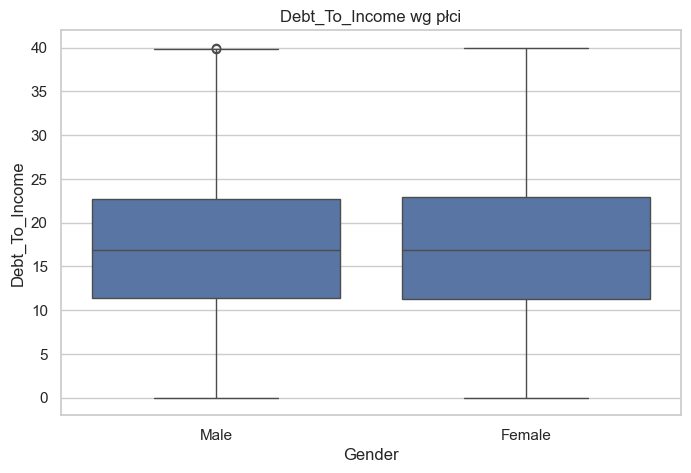

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Gender", y="Debt_To_Income")
plt.title("Debt_To_Income wg płci")
plt.show()

# Test t Welcha

In [6]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    female,
    male,
    equal_var=False
)

print("t =", round(t_stat, 4))
print("p-value =", p_value)

t = 0.679
p-value = 0.4971497533780724


# Cohens

In [7]:
import numpy as np

def cohens_d(x, y):

    pooled_sd = np.sqrt(
        (
            (len(x)-1)*np.var(x, ddof=1)
            + (len(y)-1)*np.var(y, ddof=1)
        )
        /
        (len(x)+len(y)-2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_sd

d = cohens_d(female, male)

print("Cohen's d =", round(d, 4))

Cohen's d = 0.0083


# Mann-Whitney

In [8]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    female,
    male,
    alternative="two-sided"
)

print("U =", u_stat)
print("p-value =", p_value)

U = 110117082.0
p-value = 0.5892869050159382


# Analiza 2 - Income_Verified vs Annual_Income
Sprawdzenie, czy osoby z potwierdzonym dochodem mają wyższy dochód roczny.

* H₀: Średni dochód roczny jest taki sam w obu grupach.
* H₁: Średni dochód roczny różni się między grupami.

Zmienne:
* Annual_Income - ilościowa
* Income_Verified - dwie grupy

Testy:
* t Welch
* U Mann-Whitney

# Przygotowanie danych

In [ ]:
income_df = df.dropna(subset=["Annual_Income"])

verified = income_df.loc[
    income_df["Income_Verified"] != "not verified",
    "Annual_Income"
]

not_verified = income_df.loc[
    income_df["Income_Verified"] == "not verified",
    "Annual_Income"
]

print(len(verified))
print(len(not_verified))

19007
8887


# Statystyki opisowe

In [10]:
income_df["Verified_Group"] = np.where(
    income_df["Income_Verified"] == "not verified",
    "Not verified",
    "Verified"
)

income_df.groupby("Verified_Group")["Annual_Income"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Verified_Group,,,,
Not verified,8887,63293.212171,56000.0,33103.069872
Verified,19007,76972.762402,65000.0,51510.999514


# T welch

In [11]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    verified,
    not_verified,
    equal_var=False
)

print("t =", round(t_stat, 4))
print("p-value =", p_value)

t = 26.6791
p-value = 1.1438791268505082e-154


# Mann-Whitney

In [12]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    verified,
    not_verified,
    alternative="two-sided"
)

print("U =", u_stat)
print("p-value =", p_value)

U = 99738796.0
p-value = 2.184232914218386e-131


# Cohens d

In [13]:
d = cohens_d(verified, not_verified)

print("Cohen's d =", round(d, 4))

Cohen's d = 0.2945


# Analiza 3 - Boostrap dla różnicy średnich
Oszacowanie przedziału ufności dla różnicy średnich dochodów między osobami z dochodem zweryfikowanym i nieweryfikowanym.

Różnica średnich:
- μ₁ − μ₂

# Obserwowana różnica średnich

In [14]:
observed_diff = verified.mean() - not_verified.mean()

print("Różnica średnich =", round(observed_diff, 2))

Różnica średnich = 13679.55


# Bootstrap

In [15]:
rng = np.random.default_rng(42)

n_boot = 10000

boot_diffs = []

for _ in range(n_boot):

    sample_verified = rng.choice(
        verified,
        size=len(verified),
        replace=True
    )

    sample_not_verified = rng.choice(
        not_verified,
        size=len(not_verified),
        replace=True
    )

    diff = (
        np.mean(sample_verified)
        - np.mean(sample_not_verified)
    )

    boot_diffs.append(diff)

boot_diffs = np.array(boot_diffs)

# Przedział ufności 95%

In [16]:
ci_lower, ci_upper = np.percentile(
    boot_diffs,
    [2.5, 97.5]
)

print("95% CI:")
print(ci_lower, ci_upper)

95% CI:
12682.441306154515 14685.12336707124


# Histogram bootstrap

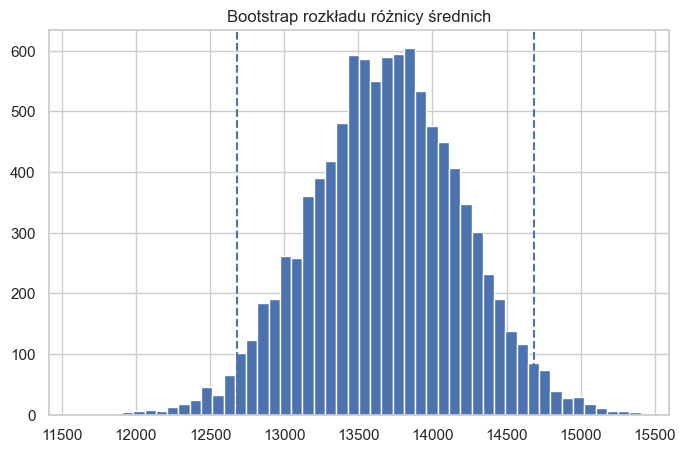

In [17]:
plt.figure(figsize=(8,5))
plt.hist(boot_diffs, bins=50)

plt.axvline(ci_lower, linestyle="--")
plt.axvline(ci_upper, linestyle="--")

plt.title("Bootstrap rozkładu różnicy średnich")
plt.show()

# Podsumowanie wyników analizy statystycznej

## 1. Wpływ płci na wskaźnik Debt_To_Income

Przeprowadzono analizę porównującą wartości wskaźnika `Debt_To_Income` między kobietami i mężczyznami.

### Wyniki
- Średnia dla kobiet: **17.27**
- Średnia dla mężczyzn: **17.20**
- Test t-Studenta: **p = 0.497**
- Test Manna–Whitneya: **p = 0.589**
- Cohen's d: **0.008**

### Wniosek
Nie stwierdzono istotnych statystycznie różnic w poziomie wskaźnika `Debt_To_Income` pomiędzy kobietami i mężczyznami. Wielkość efektu jest praktycznie zerowa, co wskazuje na brak znaczącego wpływu płci na analizowaną zmienną.

---

## 2. Wpływ weryfikacji dochodu na wysokość dochodów

Przeprowadzono analizę porównującą dochody osób z dochodem zweryfikowanym oraz nieweryfikowanym.

### Wyniki
- Średni dochód (Not Verified): **63 293**
- Średni dochód (Verified): **76 973**
- Różnica średnich: **13 680**
- Test t-Studenta: **p < 0.001**
- Test Manna–Whitneya: **p < 0.001**
- Cohen's d: **0.295**
- Bootstrapowy 95% przedział ufności dla różnicy średnich:
  **[12 682 ; 14 685]**

### Wniosek
Osoby posiadające zweryfikowany dochód osiągają istotnie wyższe dochody niż osoby bez weryfikacji. Uzyskana różnica jest statystycznie istotna i została potwierdzona zarówno przez testy statystyczne, jak i analizę bootstrapową. Wielkość efektu można określić jako małą do umiarkowanej.

---

## Wnioski końcowe

1. Nie wykazano związku między płcią a wartością wskaźnika `Debt_To_Income`.
2. Stwierdzono istotny związek między statusem weryfikacji dochodu a wysokością dochodów – osoby z dochodem zweryfikowanym osiągają przeciętnie wyższe dochody.
3. Analiza bootstrapowa potwierdziła stabilność i wiarygodność oszacowanej różnicy dochodów między badanymi grupami.